In [1]:
from matplotlib import pyplot as plt
# from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import numpy as np

from pySTDLM.PostProcessing import *

In [2]:
plt.rcParams['figure.dpi'] = 300

In [3]:
normDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_Multi_Cell_Norm/'
hypDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_Multi_Cell_Hyp/'

In [4]:
def getSplicingRatio(filename, ir=False):

    # print(filename)

    mrna = []
    fractions = []

    fileHandle = openLMFile(filename)
    rep = 1
    avTot = None
    
    CMEspecies = getSpecies(fileHandle)
    specList = [spec.decode('utf-8') for spec in CMEspecies]
    
    for i in range(len(specList)):
        spec = specList[i]
        CMEid = CMEspecies[i]
        # print(spec)
        if spec.startswith('m_'):
            # print(spec)
            mrna.append(CMEid)

    mrna.sort()

    for spec in mrna:
        av, var, t = getAvgVarTrace(fileHandle, specie=spec)
        if avTot is None:
            avTot = av
        else:
            avTot = avTot + av

        fractions.append(av[-1])

    if avTot[-1]<0.9999:
        print(f'Incomplete splicing in {filename} {avTot[-1]}')
        if ir:
            fractions[0] = fractions[0] + (1-avTot[-1])
    
    closeLMFile(fileHandle)

    return fractions

In [5]:
datasets = [
    [(0.174+0.161)/2, (0.418+0.368)/2], # MCF7
    [(0.72+0.669+0.737)/3, (0.913+0.924+0.916)/3], # MCF7 3D
    [(0.339+0.312)/2, (0.553+0.6)/2] # MCF10A
]
    # [0.3, 0.32], # MDA MB 231
# datasets

normExp = [(0.174+0.161)/2, (0.72+0.669+0.737)/3, (0.339+0.312)/2]
hypExp = [(0.418+0.368)/2, (0.913+0.924+0.916)/3, (0.553+0.6)/2]

normExpStd = [np.std(np.array([0.174,0.161])), np.std(np.array([0.72,0.669,0.737])), np.std(np.array([0.339,0.312]))]
hypExpStd = [np.std(np.array([0.418,0.368])), np.std(np.array([0.913,0.924,0.916])), np.std(np.array([0.553,0.6]))]

print(normExp)
print(normExpStd)
print(hypExp)
print(hypExpStd)

[0.16749999999999998, 0.7086666666666667, 0.3255]
[0.006499999999999992, 0.02889444391035909, 0.013500000000000012]
[0.393, 0.9176666666666667, 0.5765]
[0.024999999999999994, 0.004642796092394711, 0.023499999999999965]


[0.16749999999999998, 0.229, 0.7086666666666667, 0.299, 0.3255, 0.318]
[0.393, 0.333, 0.9176666666666667, 0.524, 0.5765, 0.603]


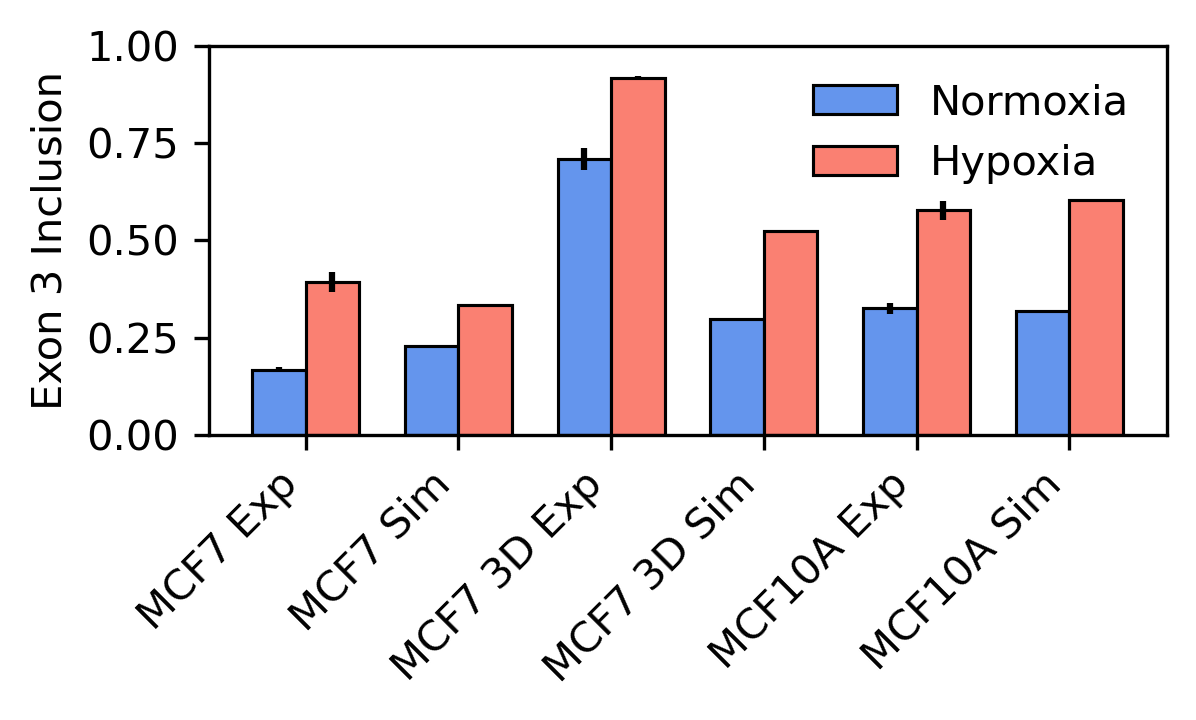

In [6]:
fig, ax = plt.subplots(figsize=(4,2.5))

barwidth = 0.35
alpha = 0.75

# ax.axhline(y=((0.174+0.161)/2), color='k', linestyle=':', label='MCF7 Normoxia')
# ax.axhline(y=((0.418+0.368)/2), color='k', linestyle='--', label='MCF7 Hypoxia')

# x0 = np.arange(len(normExp)) + 1

# ax.bar(x0 - barwidth/2, normExp, yerr=normStd, width=barwidth, color='cornflowerblue', label='Normoxia', edgecolor='k', linewidth=0.75)
# ax.bar(x0 + barwidth/2, hypExp, yerr=hypStd, width=barwidth, color='salmon', label='Hypoxia', edgecolor='k', linewidth=0.75)

normInc = []
hypInc = []

normStd = []
hypStd = []

for i in range(1,4):

    normInc.append(normExp[i-1])

    normStd.append(normExpStd[i-1])
    
    filename = f'{normDir}SRSF6_{i}.lm'
    fin = getSplicingRatio(filename)
    normInc.append(fin[0])

    normStd.append(0)

    hypInc.append(hypExp[i-1])

    hypStd.append(hypExpStd[i-1])

    filename = f'{hypDir}SRSF6_{i}.lm'
    fih = getSplicingRatio(filename)
    hypInc.append(fih[0])

    hypStd.append(0)


x1 = np.arange(len(normInc))

print(normInc)
print(hypInc)

# print(normInc)

ax.bar(x1 - barwidth/2, normInc, yerr=normStd, width=barwidth, color='cornflowerblue', label='Normoxia', edgecolor='k', linewidth=0.75)
ax.bar(x1 + barwidth/2, hypInc, yerr=hypStd, width=barwidth, color='salmon', label='Hypoxia', edgecolor='k', linewidth=0.75)

ax.set_ylabel('Exon 3 Inclusion')
# ax.set_xlabel('Computational Dataset (1,000 mRNA per Dataset)')

ax.set_ylim(0,1)

ax.xaxis.set_ticks(x1)
tickLabels = ['MCF7 Exp', 'MCF7 Sim', 'MCF7 3D Exp', 'MCF7 3D Sim', 'MCF10A Exp', 'MCF10A Sim']

ax.xaxis.set_ticklabels(tickLabels, rotation=45, ha='right')

ax.legend(loc='upper right', frameon=False)

plt.tight_layout()

plt.savefig('./multi_cell_SRSF6.png', transparent=True)

In [7]:
normStd

[0.006499999999999992, 0, 0.02889444391035909, 0, 0.013500000000000012, 0]

In [8]:
hypStd

[0.024999999999999994, 0, 0.004642796092394711, 0, 0.023499999999999965, 0]